# GNB 12 feature

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import xgboost

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

from sklearn.naive_bayes import GaussianNB

In [3]:
dataset = pd.read_csv("../../datasets/processed/cdc_diabetes.csv" , sep = "," , encoding = 'utf-8')
print("Dataset Shape: ", dataset.shape)
dataset

Dataset Shape:  (229474, 12)


,Diabetes_binary,HighBP,HighChol,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,GenHlth,MentHlth,PhysHlth,DiffWalk,Age
0,0,1,1,40,1,0,0,5,18,15,1,9
1,0,0,0,25,1,0,1,3,0,0,0,7
2,0,1,1,28,0,0,0,5,30,30,1,9
3,0,1,0,27,0,0,1,2,0,0,0,11
4,0,1,1,24,0,0,1,2,3,0,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...
229469,0,1,1,45,0,0,0,3,0,5,0,5
229470,1,1,1,18,0,0,0,4,0,0,1,11
229471,0,0,0,28,0,0,1,1,0,0,0,2
229472,0,1,0,23,0,0,0,3,0,0,0,7


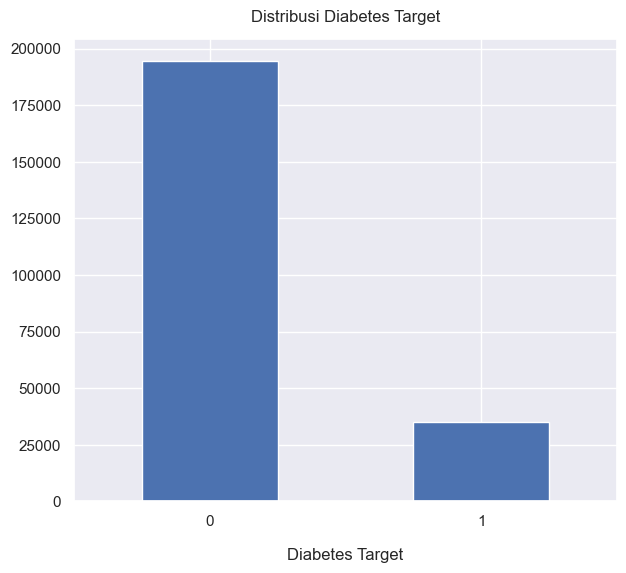

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64


In [4]:
sns.set(font_scale=1.0)
dataset['Diabetes_binary'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)
plt.xlabel("Diabetes Target", labelpad=14)
plt.title("Distribusi Diabetes Target", y=1.02);
plt.show()

print(dataset['Diabetes_binary'].value_counts())

# Balancing Data

In [5]:
X = dataset.drop(['Diabetes_binary'], axis = 1).values
y = dataset['Diabetes_binary']

## Over-Sampling SMOTE

In [6]:
# SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = SMOTE().fit_resample(X, y)

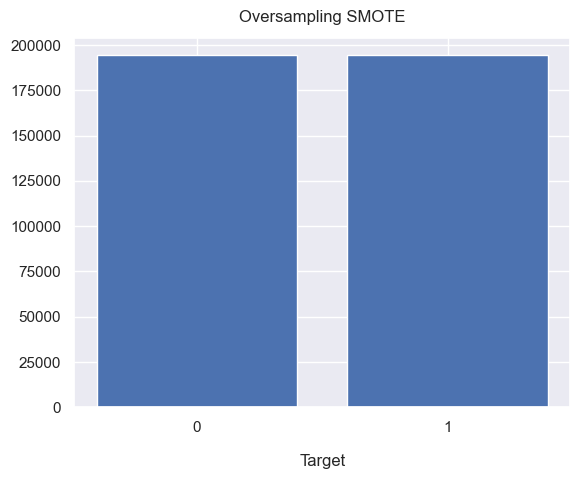

Diabetes_binary
0    194377
1    194377
Name: count, dtype: int64

In [7]:
# Oversampling SMOTE
sns.set(font_scale=1.0)
smote_counts = y_resampled_smote.value_counts()

plt.bar(smote_counts.index, smote_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Oversampling SMOTE", y=1.02);
plt.show()

smote_counts

## Under-Sampling RandomUnderSampler

In [8]:
# RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled_rus, y_resampled_rus = rus.fit_resample(X, y)

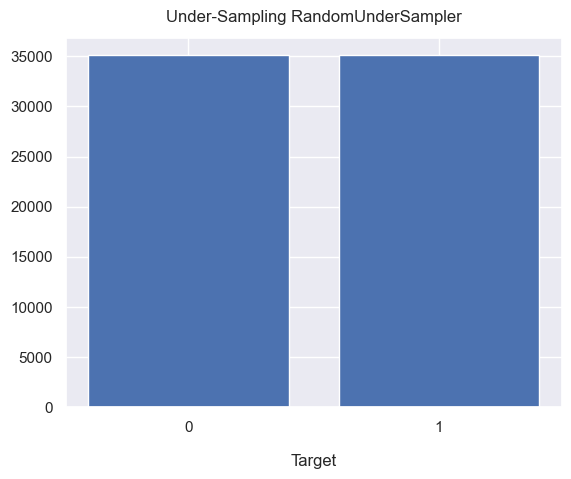

Diabetes_binary
0    35097
1    35097
Name: count, dtype: int64

In [9]:
# Under-Sampling RandomUnderSampler
sns.set(font_scale=1.0)
rus_counts = y_resampled_rus.value_counts()

plt.bar(rus_counts.index, rus_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Under-Sampling RandomUnderSampler", y=1.02);
plt.show()

rus_counts

## Over- and Under-Sampling SMOTEENN

In [10]:
# SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_resampled_smoteenn, y_resampled_smoteenn = smoteenn.fit_resample(X, y)

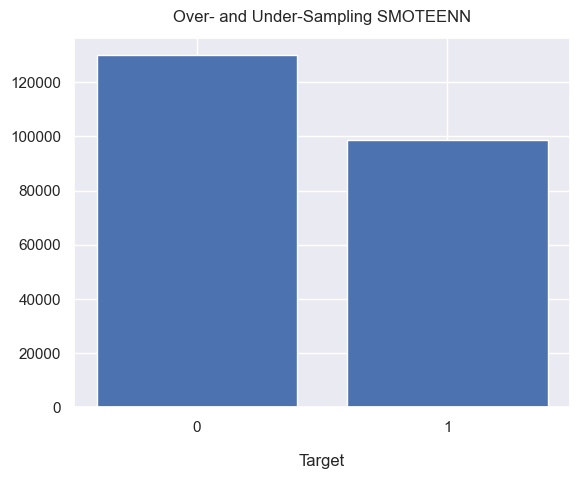

Diabetes_binary
0    129981
1     98870
Name: count, dtype: int64

In [11]:
# Over- and Under-Sampling SMOTEENN
sns.set(font_scale=1.0)
smoteenn_counts = y_resampled_smoteenn.value_counts()

plt.bar(smoteenn_counts.index, smoteenn_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Over- and Under-Sampling SMOTEENN", y=1.02);
plt.show()

smoteenn_counts

# Split Data

In [12]:
#Data Raw
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(183579, 45895, 183579, 45895)

In [13]:
# Oversampling SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_resampled_smote, y_resampled_smote,
                                                                            test_size=0.2, random_state=42)
len(X_train_smote), len(X_test_smote), len(y_train_smote), len(y_test_smote)

(311003, 77751, 311003, 77751)

In [14]:
# Under-Sampling RandomUnderSampler
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(X_resampled_rus, y_resampled_rus,
                                                                    test_size=0.2, random_state=42)
len(X_train_rus), len(X_test_rus), len(y_train_rus), len(y_test_rus)

(56155, 14039, 56155, 14039)

In [15]:
# Over- and Under-Sampling SMOTEENN
X_train_smoteenn, X_test_smoteenn, y_train_smoteenn, y_test_smoteenn = train_test_split(X_resampled_smoteenn, y_resampled_smoteenn,
                                                                    test_size=0.2, random_state=42)
len(X_train_smoteenn), len(X_test_smoteenn), len(y_train_smoteenn), len(y_test_smoteenn)

(183080, 45771, 183080, 45771)

# Model

In [16]:
# Raw Data
model = GaussianNB() 
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [17]:
# Over-Sampling SMOTE
model_smote = GaussianNB() 
model_smote.fit(X_train_smote, y_train_smote)

,priors,None
,var_smoothing,1e-09


In [18]:
# Under-Sampling RandomUnderSampler
model_rus = GaussianNB() 
model_rus.fit(X_train_rus, y_train_rus)

,priors,None
,var_smoothing,1e-09


In [19]:
# Over and Under-Sampling SMTOEENN
model_smoteenn = GaussianNB() 
model_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)

,priors,None
,var_smoothing,1e-09


In [20]:
# Raw Data
y_test_pred = model.predict(X_test)

print("\nTest Set:")
print(classification_report(y_test, y_test_pred))

accuracy_test = accuracy_score(y_test, y_test_pred)

print("\nTest Set Accuracy:", accuracy_test)


Test Set:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87     38813
           1       0.35      0.47      0.40      7082

    accuracy                           0.78     45895
   macro avg       0.62      0.65      0.63     45895
weighted avg       0.81      0.78      0.80     45895


Test Set Accuracy: 0.7829611068743871


In [21]:
# Over-Sampling SMOTE
y_test_pred_smote = model_smote.predict(X_test_smote)

print("\nTest Set:")
print(classification_report(y_test_smote, y_test_pred_smote))

accuracy_test_smote = accuracy_score(y_test_smote, y_test_pred_smote)

print("\nTest Set Accuracy:", accuracy_test_smote)


Test Set:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69     38930
           1       0.70      0.61      0.65     38821

    accuracy                           0.67     77751
   macro avg       0.67      0.67      0.67     77751
weighted avg       0.67      0.67      0.67     77751


Test Set Accuracy: 0.6721971421589433


In [22]:
# Under-Sampling RandomUnderSampler
y_test_pred_rus = model_rus.predict(X_test_rus)

print("\nTest Set:")
print(classification_report(y_test_rus, y_test_pred_rus))

accuracy_test_rus = accuracy_score(y_test_rus, y_test_pred_rus)

print("\nTest Set Accuracy:", accuracy_test_rus)


Test Set:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71      7012
           1       0.72      0.64      0.68      7027

    accuracy                           0.69     14039
   macro avg       0.70      0.69      0.69     14039
weighted avg       0.70      0.69      0.69     14039


Test Set Accuracy: 0.6947076002564285


In [23]:
# Over and Under-Sampling SMTOEENN
y_test_pred_smoteenn = model_smoteenn.predict(X_test_smoteenn)

print("\nTest Set:")
print(classification_report(y_test_smoteenn, y_test_pred_smoteenn))

accuracy_test_smoteenn = accuracy_score(y_test_smoteenn, y_test_pred_smoteenn)

print("\nTest Set Accuracy:", accuracy_test_smoteenn)


Test Set:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     25890
           1       0.80      0.76      0.78     19881

    accuracy                           0.81     45771
   macro avg       0.81      0.81      0.81     45771
weighted avg       0.81      0.81      0.81     45771


Test Set Accuracy: 0.8133097376067816


# Comparison

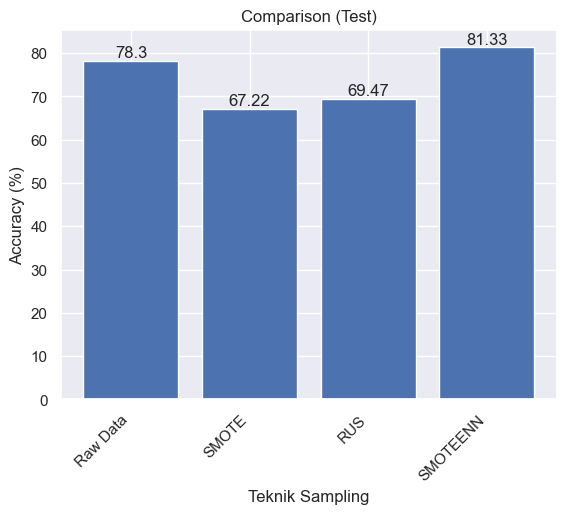

In [24]:
model_comp = pd.DataFrame({'Teknik Sampling': ['Raw Data','SMOTE','RUS', 'SMOTEENN'],
                           'Accuracy': [accuracy_test*100, accuracy_test_smote*100, accuracy_test_rus*100, accuracy_test_smoteenn*100]})

fig, ax = plt.subplots()
bars = plt.bar(model_comp['Teknik Sampling'], model_comp['Accuracy'])
plt.xlabel('Teknik Sampling')
plt.ylabel('Accuracy (%)')
plt.title('Comparison (Test)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

In [25]:
import joblib
joblib.dump(model_smoteenn, '../../models/se/GNB_12feat.pkl')

['../../models/se/GNB_12feat.pkl']